In [1]:
## Requires Python 3.9 or lower for FlowCytometryTools
import glob
import os
import numpy as np
import pandas as pd
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import FlowCytometryTools
from FlowCytometryTools import FCMeasurement
from sklearn.mixture import GaussianMixture
from scipy.stats import gaussian_kde
from collections import Counter

ip =  1/1.46

plt.style.use('styleNB.mplstyle')


# Load in data

In [2]:
# Migration track data
df = pd.read_csv('../../data/processed_2D_tracking/20250527_MDCK_filtered_tracks_compiled.csv')

# Drop few frames with drift at the start.
# {'scope': 'Rio', 'date': 20250506, 'E_V_cm' : 3, 'celltype': 'CR02-high'}
filtered_df = df[
    (df['scope'] == 'Rio') &
    (df['date'] == 20250506) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'CR02-high') &
    (df['frame'] >= 1)
].copy()

# add back in
df = df[~(
    (df['scope'] == 'Rio') &
    (df['date'] == 20250506) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'CR02-high')
)]
df = pd.concat([df, filtered_df], ignore_index=True)


# {'scope': 'Rio', 'date': 20250507, 'E_V_cm' : 3, 'celltype': 'WT-parental'}
filtered_df = df[
    (df['scope'] == 'Rio') &
    (df['date'] == 20250507) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'WT-parental') &
    (df['frame'] > 2)
].copy()

# add back in
df = df[~(
    (df['scope'] == 'Rio') &
    (df['date'] == 20250507) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'WT-parental')
)]
df = pd.concat([df, filtered_df], ignore_index=True)

######################################
######################################

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'scope', 'position', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 15:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'scope': g[5],
            'position': g[6],
            'cell': g[7],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_filtered_tracks.celltype.unique()
df = df_filtered_tracks

# Flow cytometry data
files = glob.glob('../../data/flow_cytometry/20250514_MDCK/*.fcs')



In [3]:
dict_EF = {'0' : 0, 
           '3' : 1}

# Plotting - All cells (single cells and clusters)

Missing frame at t=3 or t-2=1 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=5 or t-2=3 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=7 or t-2=5 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=13 or t-2=11 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=15 or t-2=13 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=19 or t-2=17 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=21 or t-2=19 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=19 or t-2=17 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=21 or t-2=19 for cell 31 in group (20250506, 'Rio', 20)
Missing frame at t=6 or t-2=4 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=8 or t-2=6 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=12 or t-2=10 for cell 0 in grou

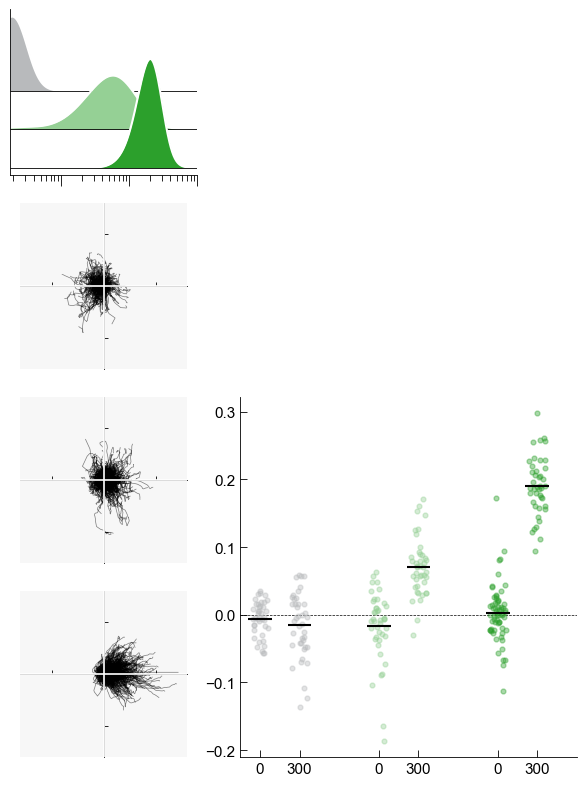

In [36]:
from matplotlib.pyplot import GridSpec
from scipy.stats import gaussian_kde
from collections import Counter

fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df[df.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df[df.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1
    
  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df[df.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)



ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

plt.savefig('../../figures/20250521_MDCK_compiled.pdf', bbox_inches='tight')

# Consider single cells

In [5]:
# Migration track data
df_single = pd.read_csv('../../data/processed_2D_tracking/20250527_MDCK_filtered_tracks_singlecells.csv')
# Drop few frames with drift at the start.
# {'scope': 'Rio', 'date': 20250506, 'E_V_cm' : 3, 'celltype': 'CR02-high'}
filtered_df = df[
    (df['scope'] == 'Rio') &
    (df['date'] == 20250506) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'CR02-high') &
    (df['frame'] >= 1)
].copy()

# add back in
df = df[~(
    (df['scope'] == 'Rio') &
    (df['date'] == 20250506) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'CR02-high')
)]
df = pd.concat([df, filtered_df], ignore_index=True)


# {'scope': 'Rio', 'date': 20250507, 'E_V_cm' : 3, 'celltype': 'WT-parental'}
filtered_df = df[
    (df['scope'] == 'Rio') &
    (df['date'] == 20250507) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'WT-parental') &
    (df['frame'] > 2)
].copy()

# add back in
df = df[~(
    (df['scope'] == 'Rio') &
    (df['date'] == 20250507) &
    (df['E_V_cm'] == 3) &
    (df['celltype'] == 'WT-parental')
)]
df = pd.concat([df, filtered_df], ignore_index=True)

######################################
######################################

# Step 2: Filter trajectories
df_filtered_tracks = pd.DataFrame()

for g, d_ in df_single.groupby(['celltype', 'E_V_cm', 'date', 'trial', 'user', 'scope', 'position', 'cell']):
    # Filter: skip short tracks based on unique frame count
    if len(d_['frame'].unique()) <= 15:
        continue

    frames = sorted(d_['frame'].unique())
    min_frame = min(frames)
    
    d_ = d_.copy()
    d_['rel_frame'] = d_['frame'] - min_frame

    # Generate a full-resolution time series
    interval_frames = np.arange(0, max(d_['rel_frame']) + 1, 1)

    positions = []
    for f in interval_frames:
        row = d_[d_['rel_frame'] == f]
        if row.empty:
            positions.append([np.nan, np.nan])
        else:
            positions.append([row.x.values[0], row.y.values[0]])

    positions = np.array(positions)
    
    # Filter: skip tracks with missing values
    if np.isnan(positions).any():
        continue
    
    # Store filtered full-resolution track with z included
    df_filtered_tracks = pd.concat([
        df_filtered_tracks,
        pd.DataFrame({
            'celltype': g[0],
            'E_V_cm': g[1],
            'date': g[2],
            'trial': g[3],
            'user': g[4],
            'scope': g[5],
            'position': g[6],
            'cell': g[7],
            'frame': interval_frames,
            'x': positions[:, 0],
            'y': positions[:, 1]
        })
    ], ignore_index=True)


df_single = df_filtered_tracks

['WT-parental'] 78
['CR01-low'] 77
['CR02-high'] 77


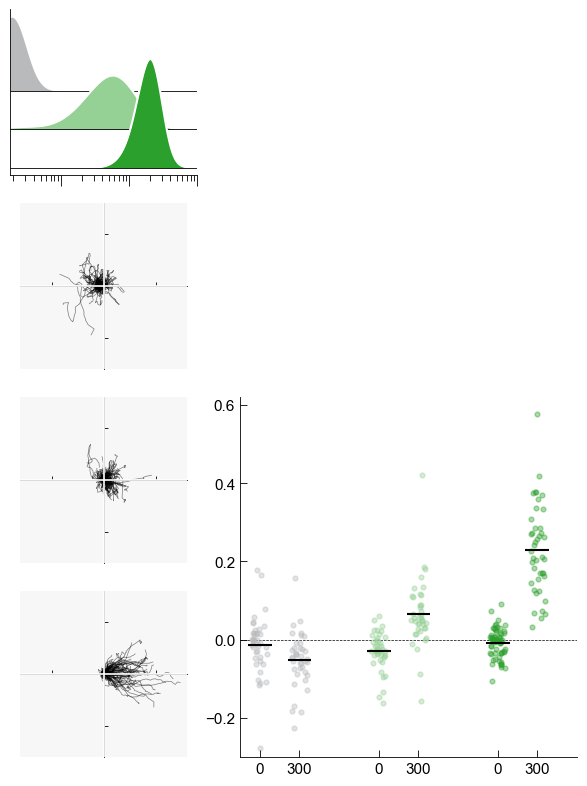

In [35]:
fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df_single[df_single.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 77:
        continue
    count_cell += 1
    
print(d_.celltype.unique(), count_cell)

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df_single[df_single.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell >= 77:
        continue
    count_cell += 1
    
print(d_.celltype.unique(), count_cell)

  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df_single[df_single.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell >= 77:
        continue
    count_cell += 1

print(d_.celltype.unique(), count_cell)

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df_single.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)



ax5.set_ylim(-0.3,0.62)
ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

plt.savefig('../../figures/20250521_MDCK_compiled_single_cells.pdf', bbox_inches='tight')

# Cell culsters (2 or more cells)

In [7]:
df_diff = df.merge(df_single, how='outer', indicator=True)
df_clusters = df_diff[df_diff['_merge'] == 'left_only'].drop(columns=['_merge'])
df_clusters.head()

,celltype,E_V_cm,date,trial,user,scope,position,cell,frame,x,y
0,CR01-low,0,20250506,0,NB,Oslo,0,3,0,520.946908,589.095950
1,CR01-low,0,20250506,0,NB,Oslo,0,3,1,519.692082,591.689040
2,CR01-low,0,20250506,0,NB,Oslo,0,3,2,519.784333,592.693157
3,CR01-low,0,20250506,0,NB,Oslo,0,3,3,519.538506,593.531422
4,CR01-low,0,20250506,0,NB,Oslo,0,3,4,520.260849,592.793850


Missing frame at t=3 or t-2=1 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=5 or t-2=3 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=7 or t-2=5 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=13 or t-2=11 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=15 or t-2=13 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=19 or t-2=17 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=21 or t-2=19 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=19 or t-2=17 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=21 or t-2=19 for cell 31 in group (20250506, 'Rio', 20)
Missing frame at t=6 or t-2=4 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=8 or t-2=6 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=12 or t-2=10 for cell 0 in grou

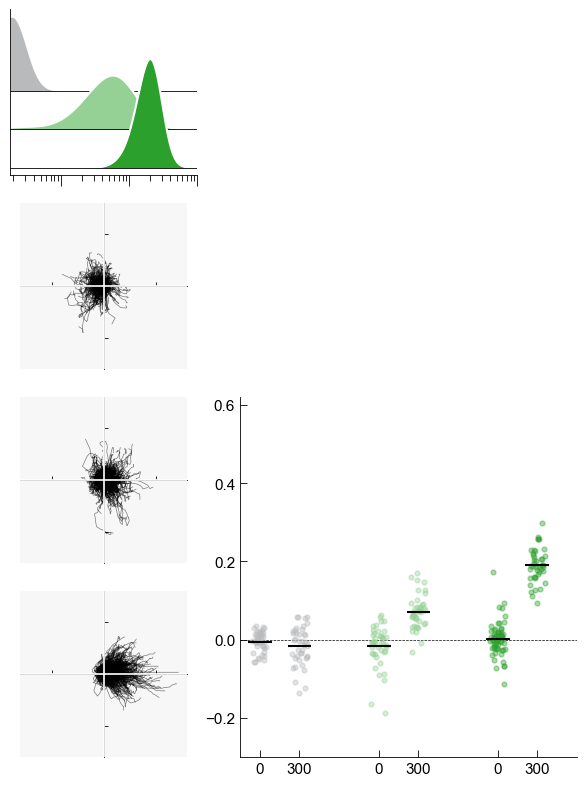

In [34]:
from matplotlib.pyplot import GridSpec
from scipy.stats import gaussian_kde
from collections import Counter

fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df_clusters[df_clusters.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df_clusters[df_clusters.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1
    
  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df_clusters[df_clusters.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df_clusters.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =12)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)


ax5.set_ylim(-0.3,0.62)
ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

plt.savefig('../../figures/20250521_MDCK_compiled_cellclusters.pdf', bbox_inches='tight')

# Statistics

In [9]:
# all the data
from scipy.stats import mannwhitneyu

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")


##################################
##################################
# Compare within each cell type (compare EF conditions) 
##################################
##################################

from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.2970, n = 41 vs 42
  WT vs CR02: p = 0.3088, n = 41 vs 63
  CR01 vs CR02: p = 0.0637, n = 42 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 41 vs 42
  WT vs CR02: p = 0.0000, n = 41 vs 42
  CR01 vs CR02: p = 0.0000, n = 42 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=42 vs 42)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.3348 (n=41 vs 41)


In [10]:
# single cells

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")



from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.1368, n = 41 vs 40
  WT vs CR02: p = 0.7095, n = 41 vs 63
  CR01 vs CR02: p = 0.0306, n = 40 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 39 vs 39
  WT vs CR02: p = 0.0000, n = 39 vs 42
  CR01 vs CR02: p = 0.0000, n = 39 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=40 vs 39)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.0032 (n=41 vs 39)


In [11]:
# cell clusters

# Create data container to store dot values per group
speed_dict = {}

# Group and extract mean dx speed per trial-level replicate
for (celltype, E_field), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    key = (E_field, celltype)
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue  # skip missing frame pairs

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_dict[key] = trial_means

# Get list of all E field strengths
all_E_fields = sorted({k[0] for k in speed_dict.keys()})

# Perform pairwise comparisons at each E field
for E in all_E_fields:
    print(f"\nE = {E} V/cm")
    
    try:
        a = speed_dict[(E, 'WT-parental')]
        b = speed_dict[(E, 'CR01-low')]
        c = speed_dict[(E, 'CR02-high')]
    except KeyError:
        print("  Missing one or more groups.")
        continue

    # WT vs CR01
    try:
        res_ab = mannwhitneyu(a, b, alternative='two-sided')
        print(f"  WT vs CR01: p = {res_ab.pvalue:.4f}, n = {len(a)} vs {len(b)}")
    except:
        print("  WT vs CR01: insufficient data")

    # WT vs CR02
    try:
        res_ac = mannwhitneyu(a, c, alternative='two-sided')
        print(f"  WT vs CR02: p = {res_ac.pvalue:.4f}, n = {len(a)} vs {len(c)}")
    except:
        print("  WT vs CR02: insufficient data")

    # CR01 vs CR02
    try:
        res_bc = mannwhitneyu(b, c, alternative='two-sided')
        print(f"  CR01 vs CR02: p = {res_bc.pvalue:.4f}, n = {len(b)} vs {len(c)}")
    except:
        print("  CR01 vs CR02: insufficient data")


from itertools import combinations

# Organize data: for each (celltype, E_V_cm), collect trial-level means
speed_by_field = {}

for (celltype, E_field), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    trial_means = []

    for (_, _, _), df_trial in df_group.groupby(['date', 'scope', 'position'], sort=False):
        cell_means = []

        for cell, d_cell in df_trial.groupby('cell'):
            d_cell = d_cell.sort_values('frame')
            tot = []

            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    dx = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(dx)
                except IndexError:
                    continue

            if len(tot) > 0:
                cell_means.append(np.mean(tot))

        if len(cell_means) > 0:
            trial_means.append(np.mean(cell_means))

    speed_by_field[(celltype, E_field)] = trial_means

# Extract all cell types and E-field conditions present
celltypes = sorted({key[0] for key in speed_by_field})
E_fields = sorted({key[1] for key in speed_by_field})

# Compare all pairs of E fields within each cell type
for celltype in celltypes:
    print(f"\n📊 Comparisons for cell type: {celltype}")

    available_fields = sorted([E for (ct, E) in speed_by_field if ct == celltype])
    for E1, E2 in combinations(available_fields, 2):
        group1 = speed_by_field.get((celltype, E1), [])
        group2 = speed_by_field.get((celltype, E2), [])

        if len(group1) > 0 and len(group2) > 0:
            res = mannwhitneyu(group1, group2, alternative='two-sided')
            print(f"  {E1} vs {E2} V/cm: p = {res.pvalue:.4f} (n={len(group1)} vs {len(group2)})")
        else:
            print(f"  {E1} vs {E2} V/cm: insufficient data")


E = 0 V/cm
  WT vs CR01: p = 0.4974, n = 41 vs 42
  WT vs CR02: p = 0.4248, n = 41 vs 63
  CR01 vs CR02: p = 0.1456, n = 42 vs 63

E = 3 V/cm
  WT vs CR01: p = 0.0000, n = 41 vs 42
  WT vs CR02: p = 0.0000, n = 41 vs 42
  CR01 vs CR02: p = 0.0000, n = 42 vs 42

📊 Comparisons for cell type: CR01-low
  0 vs 3 V/cm: p = 0.0000 (n=42 vs 42)

📊 Comparisons for cell type: CR02-high
  0 vs 3 V/cm: p = 0.0000 (n=63 vs 42)

📊 Comparisons for cell type: WT-parental
  0 vs 3 V/cm: p = 0.4415 (n=41 vs 41)


## Summary of cell numbers and replcates

In [12]:
df

,celltype,E_V_cm,date,trial,user,scope,position,cell,frame,x,y
0,CR01-low,0,20250506,0,NB,Oslo,0,3,0,520.946908,589.095950
1,CR01-low,0,20250506,0,NB,Oslo,0,3,1,519.692082,591.689040
2,CR01-low,0,20250506,0,NB,Oslo,0,3,2,519.784333,592.693157
3,CR01-low,0,20250506,0,NB,Oslo,0,3,3,519.538506,593.531422
4,CR01-low,0,20250506,0,NB,Oslo,0,3,4,520.260849,592.793850
...,...,...,...,...,...,...,...,...,...,...,...
230467,WT-parental,3,20250507,0,NB,Rio,20,23,15,259.726605,240.578469
230468,WT-parental,3,20250507,0,NB,Rio,20,23,16,256.729621,240.548348
230469,WT-parental,3,20250507,0,NB,Rio,20,23,17,255.050055,241.348840
230470,WT-parental,3,20250507,0,NB,Rio,20,23,18,254.888356,243.428028


In [13]:
# Create a new global unique cell ID per group
df['cell_global'] = (
    df['date'].astype(str) + '_' +
    df['celltype'].astype(str) + '_' +
    df['trial'].astype(str) + '_' +
    df['user'].astype(str) + '_' +
    df['position'].astype(str) + '_' +
    df['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,971
1,CR01-low,3,2,1105
2,CR02-high,0,3,1768
3,CR02-high,3,2,1504
4,WT-parental,0,2,1364
5,WT-parental,3,2,1390


In [14]:
# Create a new global unique cell ID per group
df_single['cell_global'] = (
    df_single['date'].astype(str) + '_' +
    df_single['celltype'].astype(str) + '_' +
    df_single['trial'].astype(str) + '_' +
    df_single['user'].astype(str) + '_' +
    df_single['position'].astype(str) + '_' +
    df_single['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_single.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,212
1,CR01-low,3,2,157
2,CR02-high,0,3,404
3,CR02-high,3,2,217
4,WT-parental,0,2,199
5,WT-parental,3,2,163


In [15]:
# Create a new global unique cell ID per group
df_clusters['cell_global'] = (
    df_clusters['date'].astype(str) + '_' +
    df_clusters['celltype'].astype(str) + '_' +
    df_clusters['trial'].astype(str) + '_' +
    df_clusters['user'].astype(str) + '_' +
    df_clusters['position'].astype(str) + '_' +
    df_clusters['cell'].astype(str)
)

# Group and count
summary_stats = []
for (celltype, E_V_cm), df_group in df_clusters.groupby(['celltype', 'E_V_cm']):
    n_samples = df_group.groupby(['date', 'trial', 'user']).ngroups
    n_cells = df_group['cell_global'].nunique()

    summary_stats.append({
        'celltype': celltype,
        'E_V_cm': E_V_cm,
        'n_samples': n_samples,
        'n_cells': n_cells
    })

df_summary_stats = pd.DataFrame(summary_stats).sort_values(['celltype', 'E_V_cm'])
df_summary_stats

,celltype,E_V_cm,n_samples,n_cells
0,CR01-low,0,2,759
1,CR01-low,3,2,948
2,CR02-high,0,3,1364
3,CR02-high,3,2,1408
4,WT-parental,0,2,1165
5,WT-parental,3,2,1327


# Replot with per cell scatter
- also change marker type for single cell versus cluster?

Missing frame at t=3 or t-2=1 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=5 or t-2=3 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=7 or t-2=5 for cell 1 in group (20250506, 'Rio', 1)
Missing frame at t=13 or t-2=11 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=15 or t-2=13 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=19 or t-2=17 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=21 or t-2=19 for cell 49 in group (20250506, 'Rio', 6)
Missing frame at t=17 or t-2=15 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=19 or t-2=17 for cell 23 in group (20250506, 'Rio', 11)
Missing frame at t=21 or t-2=19 for cell 31 in group (20250506, 'Rio', 20)
Missing frame at t=6 or t-2=4 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=8 or t-2=6 for cell 0 in group (20250507, 'Rio', 3)
Missing frame at t=12 or t-2=10 for cell 0 in grou

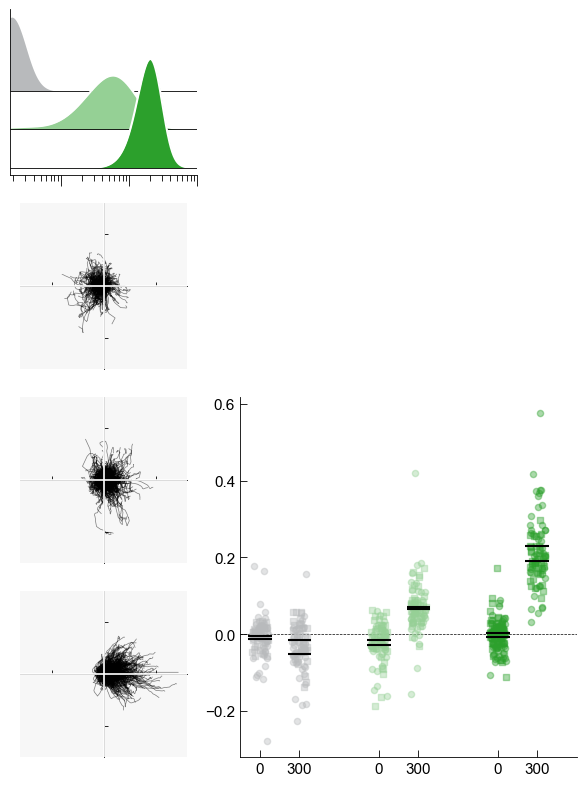

In [33]:
from matplotlib.pyplot import GridSpec
from scipy.stats import gaussian_kde
from collections import Counter

fig = plt.figure(figsize=(6,8))
gs = GridSpec(nrows=4, ncols=2,
              height_ratios=[1, 1, 1, 1],
              width_ratios=[1, 1.8])


###################################
# flow  cytometry
################################################
############################
############################
ax1 = fig.add_subplot(gs[0,0])

# Input files and labels
flow_files = [files[0], files[1], files[-1]]
# labels = ['CR02-high', 'CR01-low', 'WT-parental']
labels = ['MDCK +Galvanin-GFP\n(high expression)', 'MDCK +Galvanin-GFP\n(low expression)', 'MDCK']
colors = [(0.1725, 0.6274, 0.1725), (0.586, 0.814, 0.586), '#B8BABC']


offset = 0.75

x_shared = np.linspace(3.25, 6.6, 500)  # Shared x-grid
density_cutoff = 1e-3                   # Clip below this density threshold

for i, (f, label, color) in enumerate(zip(flow_files, labels, colors)):
    # Load and preprocess data
    sample = FCMeasurement(ID=label, datafile=f).data
    sample = sample[(sample['FSC-A'] >= 2.5E6) & 
                    (sample['SSC-A'] >= 0.4E5) & 
                    (sample['FSC-A'] <= 1.2E7)]
    data = sample.loc[sample['FITC-A'] > 0].copy()

    # remove doublets
    X = data[['FSC-A', 'FSC-H']].values
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0).fit(X)  # add random_state for consistency
    gmm_labels = gmm.predict(X)
    
    # Count points in each cluster
    counts = Counter(gmm_labels)
    singlet_label = counts.most_common(1)[0][0]  # get label of larger cluster
    
    cluster_data = data[gmm_labels == singlet_label]

    cluster_data = cluster_data.loc[cluster_data['FITC-A'] > 0].copy()
    cluster_data['FITC-A_l'] = np.log10(cluster_data['FITC-A'])

    if cluster_data.empty:
        continue

    # KDE
    kde = gaussian_kde(cluster_data['FITC-A_l'], bw_method=0.5)
    y_vals = kde(x_shared)

    # Clip tails where density is too low
    mask = y_vals > density_cutoff
    x_clipped = x_shared[mask]
    y_clipped = y_vals[mask]

    if len(x_clipped) < 2:
        continue  # Skip if nothing left to plot

    zorder = len(flow_files) - i*2

    # Fill (zorder 1)
    ax1.fill_between(x_clipped, i * offset, i * offset + y_clipped,
                     color=color, alpha=1, zorder=zorder + 1, lw = 0)
    
    # White outline (slightly higher zorder, slightly *larger* lw)
    ax1.plot(x_clipped, i * offset + y_clipped,
             color='white', lw=1.5, zorder=zorder + 1)

    ax1.hlines(i * offset, 3.25, 6.6,  # start and end of clipped region
         color='k', lw=0.6, zorder=zorder+2)  # style to match KDE outline

    # Label
    # ax1.text(6.65, i * offset + max(y_clipped) * 0.4, label, fontsize=10, va='center', zorder=zorder + 2)


# Style
sns.despine(left=True, bottom=False)


############################
EF_dict = {'0' : 0, 
           '3' : 1}

dict_ax = {'WT-parental' : 0, 'CR01-low' : 1, 'CR02-high' : 2}
############################

ax2 = fig.add_subplot(gs[1,0])


df_temp = df[df.celltype == 'WT-parental']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['WT-parental', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax2.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax2.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

############################

ax3 = fig.add_subplot(gs[2,0])


df_temp = df[df.celltype == 'CR01-low']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR01-low', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax3.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax3.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1
    
  ############################

ax4 = fig.add_subplot(gs[3,0])


df_temp = df[df.celltype == 'CR02-high']
df_temp = df_temp[df_temp.E_V_cm == 3]

g = ['CR02-high', '3']

count_cell = 0
for i, d_ in df_temp.groupby(['cell', 'date', 'scope', 'celltype', 'position']):

    # cells_ = dict_test[(i[1],i[2], g[0], g[1])][i[-1]]
    # if i[0] not in cells_:
    #     continue
    if len(d_.frame) <30:
        continue

    t0_x = d_[d_.frame == d_.frame.min()].x.values
    t0_y = d_[d_.frame == d_.frame.min()].y.values

    if np.shape(t0_x)== (0,):
        continue
    if len(d_.x.values) != len(d_.y.values):
        continue

    ax4.plot(d_.x - t0_x, 
                   d_.y - t0_y, color = 'k', alpha = 0.5, lw = 0.5, zorder = 20)
    # ax4.set_xlabel(r'x position ($\mu$m)')
    # ax4.set_ylabel(r'y position ($\mu$m)')

    if count_cell > 100:
        continue
    count_cell += 1

# Enforce identical limits explicitly
xlim = (-160, 160)
ylim = (-160, 160)

for ax_ in [ax2, ax3, ax4]:
    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    
for ax_ in [ax2, ax3, ax4]:
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)

    ax_.set_xlim(xlim)
    ax_.set_ylim(ylim)
    ax_.set_aspect('equal', adjustable='box')  # force 1:1 scaling
    ax_.set_axisbelow(True)

for ax_ in [ax2, ax3, ax4]:
    # Draw white zero lines to emphasize axes
    ax_.axhline(0, color='white', lw=1.2, zorder=100)
    ax_.axvline(0, color='white', lw=1.2, zorder=100)

    # Enhance axis settings
    ax_.spines['left'].set_position(('data', 0))
    ax_.spines['bottom'].set_position(('data', 0))
    ax_.xaxis.set_label_coords(0.6, -0.05)
    ax_.yaxis.set_label_coords(0.0, 0.6)
    # ax_.set_xlim(-400, 400)
    # ax_.set_ylim(-400, 400)
    ax_.set_axisbelow(True)
    ax_.set_aspect('equal')  # Equal scaling for x and y
    ax_.set_facecolor('#f7f7f7')  # soft background for contrast

    # Remove all tick labels
    ax_.set_xticklabels([])
    ax_.set_yticklabels([])

    # Optional: reduce tick mark length
    ax_.tick_params(length=3)
    
############################
############################
ax5 = fig.add_subplot(gs[2:,1])

color_dict = {'WT-parental': '#B8BABC',
 'CR01-low': (0.5862745098039216, 0.8137254901960784, 0.5862745098039216),
 'CR02-high': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313)}


dict_EF = {0 : 0, 
           3 : 1}

dict_x = {'WT-parental' : 0, 'CR01-low' : 3, 'CR02-high' : 6}

for sg, d_ in df_clusters.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        marker = 's',
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =20)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)


for sg, d_ in df_single.groupby(['celltype', 'E_V_cm']):
    dot_group = []
    dot_all = []
    for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
        dot = []
        for cell, d_cell in d.groupby('cell'):

            unique_frames = d_cell.frame.unique()
            frame_range = np.arange(d_cell.frame.min(), d_cell.frame.max() + 1)

            tot = []
            for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                try:
                    val = (d_cell[d_cell.frame == t].x.values[0] - d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                    tot.append(val)
                except IndexError:
                    print(f"Missing frame at t={t} or t-2={t-2} for cell {cell} in group {g}")
            if len(tot) > 0:
                dot.append(np.mean(tot))

                dot_all = np.append(dot_all, np.mean(tot))

    
        if len(dot) > 0:
            ax5.scatter(dict_x[sg[0]] + np.random.uniform(-0.2, 0.2) + dict_EF[sg[1]], np.mean(dot), 
                        marker = 'o',
                        alpha=0.4, color=color_dict[sg[0]], zorder=1, s =20)
            dot_group = np.append(dot_group, np.mean(dot))

    ax5.hlines(np.mean(dot_group), dict_x[sg[0]] + dict_EF[sg[1]] - 0.3, dict_x[sg[0]] + dict_EF[sg[1]] + 0.3, alpha=1, 
                                       color = 'k', linewidth = 1.5, zorder = 10)

    
ax5.set_xlim(-0.5,8)
ax5.hlines(0,-0.5, 8, linestyle = '--', linewidth = 0.5, color = 'k', zorder = 0)
# ax5.set_ylabel('average speed along electric\n'
#                 r'field direction ($\mu$m/min)')
# ax5.set_xlabel('electric field strength (mV/mm)')

# Define the tick positions and labels
xtick_positions = [0, 1, 3, 4, 6, 7]
xtick_labels = ['0', '300', '0', '300', '0', '300']

ax5.set_xticks(xtick_positions)
ax5.set_xticklabels(xtick_labels)


ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(True)
ax1.axes.get_yaxis().set_visible(False)
ax1.set_xlabel(None)
ax1.set_ylabel(None)
ax1.set_xticklabels([])
ax1.tick_params(which='major', length=8, direction='in')
ax1.tick_params(which='minor', length=4, direction='in')
# ax1.set_xlabel('fluorescence intensity\n(Galvanin-GFP, a.u.)')

# Major ticks
ax1.set_xticks(np.log10([100, 1000, 10000, 100000, 1000000]))
# Minor ticks
ax1.set_xticks(np.log10([
    200, 300, 400, 500, 600, 700, 800, 900,
    2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000,
    20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000,
    200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000,
    2000000, 3000000
]), minor=True)

# Tick formatting and styling
ax1.tick_params(which='major', length=8, direction='out', bottom=True)
ax1.tick_params(which='minor', length=4, direction='out', bottom=True)

ax1.set_xlim(3.25, 6)
ax1.set_autoscale_on(False)

for spine in ax1.spines.values():
    spine.set_zorder(10)  # Increase zorder to bring to front

    
plt.tight_layout()

plt.savefig('../../figures/20250521_MDCK_compiled.pdf', bbox_inches='tight')

In [17]:
group_order = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]

x_positions = {}
x_tick_labels = []

group_spacing = 2.0   # spacing between EF groups (reduce this to make them closer)
within_group_spacing = 0.6  # spacing between celltypes in the same EF group

x_base = 0
for E in ef_levels:
    for i, ct in enumerate(group_order):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing  # advance to next EF block

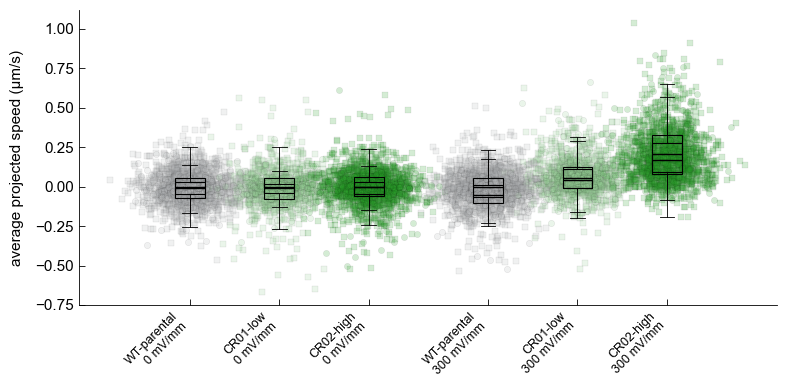

In [18]:
import matplotlib.pyplot as plt

fig, ax5 = plt.subplots(figsize=(8, 4))

jitter_scale = 0.15
marker_style = {'df_clusters': 's', 'df_single': 'o'}

for df_name, df in {'df_clusters': df_clusters, 'df_single': df_single}.items():
    for (celltype, E), d_ in df.groupby(['celltype', 'E_V_cm']):
        dot_group = []

        for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
            dot = []

            for cell, d_cell in d.groupby('cell'):
                tot = []
                for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                    try:
                        val = (d_cell[d_cell.frame == t].x.values[0] -
                               d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                        tot.append(val)
                    except IndexError:
                        continue
                if len(tot) > 0:
                    dot.append(np.mean(tot))
                    dot_group.append(np.mean(tot))

        if len(dot_group) > 0:
            xpos = x_positions[(celltype, E)]
            jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(dot_group))
            ax5.scatter(
                jittered_x, dot_group,
                alpha=0.2, s=20, zorder=1,
                color=color_dict[celltype],
                marker=marker_style[df_name],
                edgecolor='k', linewidth=0.2
            )

            # Add boxplot over same data
            ax5.boxplot(
                dot_group,
                positions=[xpos],
                widths=0.2,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(color='black', linewidth=0.6),
                capprops=dict(color='black', linewidth=0.6),
            )

ax5.set_xticks(list(x_positions.values()))
ax5.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel("average projected speed (μm/s)")
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(width=0.6, length=4)
plt.tight_layout()

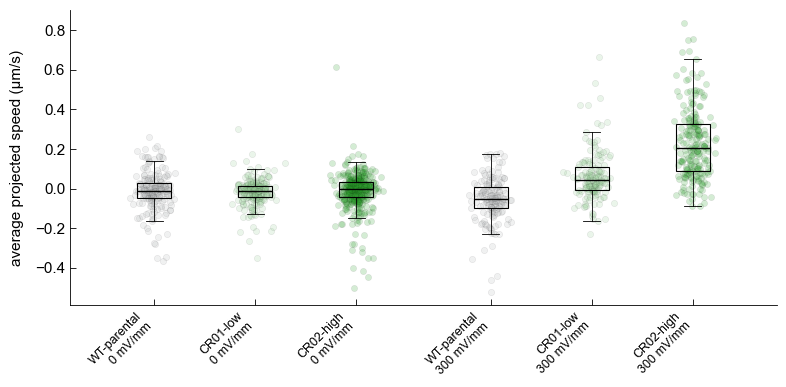

In [19]:
import matplotlib.pyplot as plt

fig, ax5 = plt.subplots(figsize=(8, 4))

jitter_scale = 0.05
marker_style = {'df_clusters': 's', 'df_single': 'o'}

for df_name, df in {'df_single': df_single}.items():
    for (celltype, E), d_ in df.groupby(['celltype', 'E_V_cm']):
        dot_group = []

        for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
            dot = []

            for cell, d_cell in d.groupby('cell'):
                tot = []
                for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                    try:
                        val = (d_cell[d_cell.frame == t].x.values[0] -
                               d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                        tot.append(val)
                    except IndexError:
                        continue
                if len(tot) > 0:
                    dot.append(np.mean(tot))
                    dot_group.append(np.mean(tot))

        if len(dot_group) > 0:
            xpos = x_positions[(celltype, E)]
            jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(dot_group))
            ax5.scatter(
                jittered_x, dot_group,
                alpha=0.2, s=20, zorder=1,
                color=color_dict[celltype],
                marker=marker_style[df_name],
                edgecolor='k', linewidth=0.2
            )

            # Add boxplot over same data
            ax5.boxplot(
                dot_group,
                positions=[xpos],
                widths=0.2,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(color='black', linewidth=0.6),
                capprops=dict(color='black', linewidth=0.6),
            )

ax5.set_xticks(list(x_positions.values()))
ax5.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel("average projected speed (μm/s)")
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(width=0.6, length=4)
plt.tight_layout()

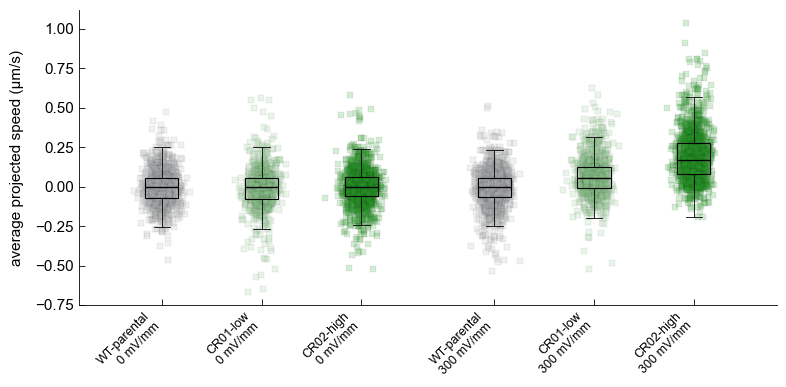

In [20]:
import matplotlib.pyplot as plt

fig, ax5 = plt.subplots(figsize=(8, 4))

jitter_scale = 0.05
marker_style = {'df_clusters': 's', 'df_single': 'o'}

for df_name, df in {'df_clusters': df_clusters}.items():
    for (celltype, E), d_ in df.groupby(['celltype', 'E_V_cm']):
        dot_group = []

        for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
            dot = []

            for cell, d_cell in d.groupby('cell'):
                tot = []
                for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                    try:
                        val = (d_cell[d_cell.frame == t].x.values[0] -
                               d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                        tot.append(val)
                    except IndexError:
                        continue
                if len(tot) > 0:
                    dot.append(np.mean(tot))
                    dot_group.append(np.mean(tot))

        if len(dot_group) > 0:
            xpos = x_positions[(celltype, E)]
            jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(dot_group))
            ax5.scatter(
                jittered_x, dot_group,
                alpha=0.2, s=20, zorder=1,
                color=color_dict[celltype],
                marker=marker_style[df_name],
                edgecolor='k', linewidth=0.2
            )

            # Add boxplot over same data
            ax5.boxplot(
                dot_group,
                positions=[xpos],
                widths=0.2,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(color='black', linewidth=0.6),
                capprops=dict(color='black', linewidth=0.6),
            )

ax5.set_xticks(list(x_positions.values()))
ax5.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel("average projected speed (μm/s)")
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(width=0.6, length=4)
plt.tight_layout()

In [21]:
group_order = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]

x_positions = {}
x_tick_labels = []

group_spacing = 2.0
within_group_spacing = 0.9

x_base = 0
for ct in group_order:
    for i, E in enumerate(ef_levels):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing

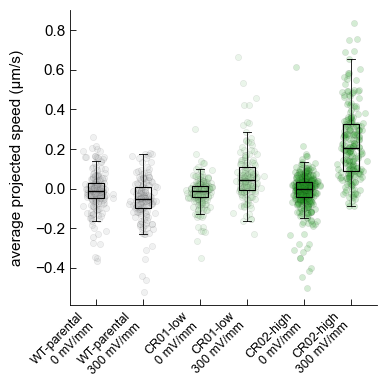

In [22]:
import matplotlib.pyplot as plt

fig, ax5 = plt.subplots(figsize=(4, 4))

jitter_scale = 0.1
marker_style = {'df_clusters': 's', 'df_single': 'o'}

for df_name, df in {'df_single': df_single}.items():
    for (celltype, E), d_ in df.groupby(['celltype', 'E_V_cm']):
        dot_group = []

        for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
            dot = []

            for cell, d_cell in d.groupby('cell'):
                tot = []
                for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                    try:
                        val = (d_cell[d_cell.frame == t].x.values[0] -
                               d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                        tot.append(val)
                    except IndexError:
                        continue
                if len(tot) > 0:
                    dot.append(np.mean(tot))
                    dot_group.append(np.mean(tot))

        if len(dot_group) > 0:
            xpos = x_positions[(celltype, E)]
            jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(dot_group))
            ax5.scatter(
                jittered_x, dot_group,
                alpha=0.2, s=20, zorder=1,
                color=color_dict[celltype],
                marker=marker_style[df_name],
                edgecolor='k', linewidth=0.2
            )

            # Add boxplot over same data
            ax5.boxplot(
                dot_group,
                positions=[xpos],
                widths=0.3,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(color='black', linewidth=0.6),
                capprops=dict(color='black', linewidth=0.6),
            )

ax5.set_xticks(list(x_positions.values()))
ax5.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel("average projected speed (μm/s)")
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(width=0.6, length=4)
plt.tight_layout()

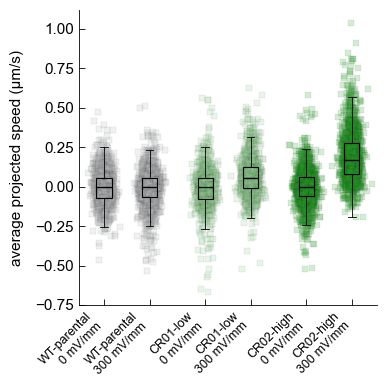

In [23]:
import matplotlib.pyplot as plt

fig, ax5 = plt.subplots(figsize=(4, 4))

jitter_scale = 0.1
marker_style = {'df_clusters': 's', 'df_single': 'o'}

for df_name, df in {'df_clusters': df_clusters}.items():
    for (celltype, E), d_ in df.groupby(['celltype', 'E_V_cm']):
        dot_group = []

        for g, d in d_.groupby(['date', 'scope', 'position'], sort=False):
            dot = []

            for cell, d_cell in d.groupby('cell'):
                tot = []
                for t in np.arange(d_cell.frame.min(), d_cell.frame.max(), 2)[1:]:
                    try:
                        val = (d_cell[d_cell.frame == t].x.values[0] -
                               d_cell[d_cell.frame == t-2].x.values[0]) / 10.0
                        tot.append(val)
                    except IndexError:
                        continue
                if len(tot) > 0:
                    dot.append(np.mean(tot))
                    dot_group.append(np.mean(tot))

        if len(dot_group) > 0:
            xpos = x_positions[(celltype, E)]
            jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(dot_group))
            ax5.scatter(
                jittered_x, dot_group,
                alpha=0.2, s=20, zorder=1,
                color=color_dict[celltype],
                marker=marker_style[df_name],
                edgecolor='k', linewidth=0.2
            )

            # Add boxplot over same data
            ax5.boxplot(
                dot_group,
                positions=[xpos],
                widths=0.3,
                patch_artist=True,
                showfliers=False,
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
                medianprops=dict(color='black', linewidth=1),
                whiskerprops=dict(color='black', linewidth=0.6),
                capprops=dict(color='black', linewidth=0.6),
            )

ax5.set_xticks(list(x_positions.values()))
ax5.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel("average projected speed (μm/s)")
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.tick_params(width=0.6, length=4)
plt.tight_layout()

## directionality

In [24]:
def calc_cos_theta_net_per_trajectory(df):
    def cos_theta_net(d):
        dx = d['x'].iloc[-1] - d['x'].iloc[0]
        dy = d['y'].iloc[-1] - d['y'].iloc[0]
        v = np.array([dx, dy])
        e_field = np.array([1, 0])  # assumes field is along +x
        norm = np.linalg.norm(v)
        if norm == 0:
            return np.nan
        return np.dot(v, e_field) / norm

    group_cols = ['celltype', 'E_V_cm', 'date', 'trial',  'scope', 'position', 'cell']
    return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')

df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df)

sample_group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'scope', 'position']
df_sample_means = (
    df_cos_theta_net_all
    .groupby(sample_group_cols)
    .agg(mean_cos_theta=('cos_theta_net', 'mean'))
    .reset_index()
)

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_67220/3077531404.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


In [25]:
group_order = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]
x_positions = {}
x_tick_labels = []

group_spacing = 2.0
within_group_spacing = 0.6
x_base = 0

for E in ef_levels:
    for i, ct in enumerate(group_order):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing

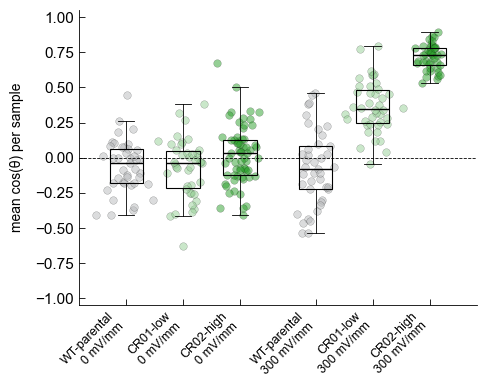

In [26]:
fig, ax = plt.subplots(figsize=(5, 4))

jitter_scale = 0.10
for (celltype, E), group in df_sample_means.groupby(['celltype', 'E_V_cm']):
    cos_vals = group['mean_cos_theta'].dropna().values
    if len(cos_vals) == 0:
        continue

    xpos = x_positions.get((celltype, E), None)
    if xpos is None:
        continue

    jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(cos_vals))
    ax.scatter(
        jittered_x, cos_vals,
        alpha=0.5, s=30, zorder=1,
        color=color_dict[celltype],
        edgecolor='k', linewidth=0.2
    )

    # Add boxplot
    ax.boxplot(
        [cos_vals],
        positions=[xpos],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(color='black', linewidth=0.6),
        capprops=dict(color='black', linewidth=0.6),
    )


ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('mean cos(θ) per sample', fontsize=10)
ax.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax.set_ylim(-1.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(width=0.6, length=4)
plt.tight_layout()

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_67220/3077531404.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


,celltype,n_0,n_3,median_0,median_3,U_stat,p_value
1,CR02-high,63,42,0.031950,0.729630,12.0,1.017444e-17
0,CR01-low,42,42,-0.036988,0.346717,95.0,1.977274e-12
2,WT-parental,41,41,-0.034002,-0.077135,882.0,7.037713e-01


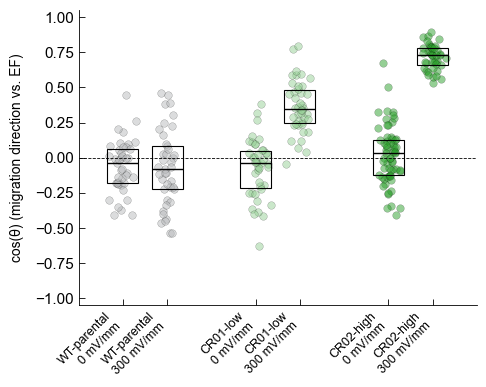

In [27]:
df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df)

sample_group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'scope', 'position']
df_sample_means = (
    df_cos_theta_net_all
    .groupby(sample_group_cols)
    .agg(mean_cos_theta=('cos_theta_net', 'mean'))
    .reset_index()
)

celltypes = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]

x_positions = {}
x_tick_labels = []

group_spacing = 1.5
within_group_spacing = 0.5
x_base = 0

for ct in celltypes:
    for i, E in enumerate(ef_levels):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing

fig, ax = plt.subplots(figsize=(5, 4))
jitter_scale = 0.06

for (celltype, E), group in df_sample_means.groupby(['celltype', 'E_V_cm']):
    cos_vals = group['mean_cos_theta'].dropna().values
    if len(cos_vals) == 0:
        continue

    xpos = x_positions[(celltype, E)]
    jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(cos_vals))

    ax.scatter(
        jittered_x, cos_vals,
        alpha=0.5, s=30, zorder=1,
        color=color_dict[celltype],
        edgecolor='k', linewidth=0.2
    )

    ax.boxplot(
        [cos_vals],
        positions=[xpos],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(color='none', linewidth=0),
        capprops=dict(color='none', linewidth=0),
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('cos(θ) (migration direction vs. EF)', fontsize=10)
ax.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax.set_ylim(-1.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(width=0.6, length=4)
plt.tight_layout()

fig.savefig('../../figures/Figure4_MDCK_directionality_all.pdf')


from scipy.stats import mannwhitneyu

results = []

for ct in df_sample_means['celltype'].unique():
    df_ct = df_sample_means[df_sample_means['celltype'] == ct]
    group_0 = df_ct[df_ct['E_V_cm'] == 0]['mean_cos_theta'].dropna()
    group_3 = df_ct[df_ct['E_V_cm'] == 3]['mean_cos_theta'].dropna()

    if len(group_0) < 2 or len(group_3) < 2:
        print(f"Not enough data to test {ct}")
        continue

    stat, p = mannwhitneyu(group_0, group_3, alternative='two-sided')
    results.append({
        'celltype': ct,
        'n_0': len(group_0),
        'n_3': len(group_3),
        'median_0': group_0.median(),
        'median_3': group_3.median(),
        'U_stat': stat,
        'p_value': p
    })

import pandas as pd
df_u_test = pd.DataFrame(results)
df_u_test.sort_values('p_value', inplace=True)

from IPython.display import display
display(df_u_test)


/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_67220/3077531404.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


,celltype,n_0,n_3,median_0,median_3,U_stat,p_value
1,CR02-high,63,42,0.041909,0.804872,77.0,3.737130e-16
0,CR01-low,40,39,-0.271098,0.382950,193.0,8.866168e-09
2,WT-parental,41,39,-0.122267,-0.437955,1135.0,1.261722e-03


0.001261722

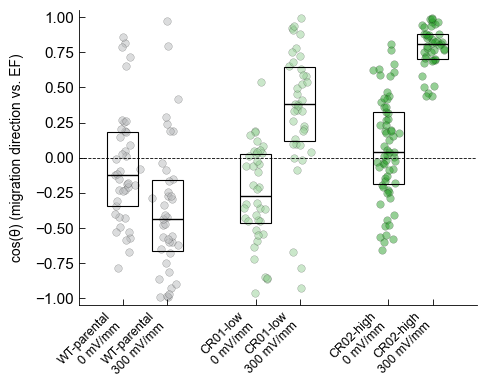

In [32]:
df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_single)

sample_group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'scope', 'position']
df_sample_means = (
    df_cos_theta_net_all
    .groupby(sample_group_cols)
    .agg(mean_cos_theta=('cos_theta_net', 'mean'))
    .reset_index()
)

celltypes = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]

x_positions = {}
x_tick_labels = []

group_spacing = 1.5
within_group_spacing = 0.5
x_base = 0

for ct in celltypes:
    for i, E in enumerate(ef_levels):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing

fig, ax = plt.subplots(figsize=(5, 4))
jitter_scale = 0.06

for (celltype, E), group in df_sample_means.groupby(['celltype', 'E_V_cm']):
    cos_vals = group['mean_cos_theta'].dropna().values
    if len(cos_vals) == 0:
        continue

    xpos = x_positions[(celltype, E)]
    jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(cos_vals))

    ax.scatter(
        jittered_x, cos_vals,
        alpha=0.5, s=30, zorder=1,
        color=color_dict[celltype],
        edgecolor='k', linewidth=0.2
    )

    ax.boxplot(
        [cos_vals],
        positions=[xpos],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(color='none', linewidth=0),
        capprops=dict(color='none', linewidth=0),
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('cos(θ) (migration direction vs. EF)', fontsize=10)
ax.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax.set_ylim(-1.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(width=0.6, length=4)
plt.tight_layout()



from scipy.stats import mannwhitneyu

results = []

for ct in df_sample_means['celltype'].unique():
    df_ct = df_sample_means[df_sample_means['celltype'] == ct]
    group_0 = df_ct[df_ct['E_V_cm'] == 0]['mean_cos_theta'].dropna()
    group_3 = df_ct[df_ct['E_V_cm'] == 3]['mean_cos_theta'].dropna()

    if len(group_0) < 2 or len(group_3) < 2:
        print(f"Not enough data to test {ct}")
        continue

    stat, p = mannwhitneyu(group_0, group_3, alternative='two-sided')
    results.append({
        'celltype': ct,
        'n_0': len(group_0),
        'n_3': len(group_3),
        'median_0': group_0.median(),
        'median_3': group_3.median(),
        'U_stat': stat,
        'p_value': p
    })

import pandas as pd
df_u_test = pd.DataFrame(results)
df_u_test.sort_values('p_value', inplace=True)

from IPython.display import display
display(df_u_test)


fig.savefig('../../figures/Figure4_MDCK_directionality_single.pdf')
1.261722e-03

In [29]:
# from scipy.stats import mannwhitneyu

# results = []

# for ct in df_sample_means['celltype'].unique():
#     df_ct = df_sample_means[df_sample_means['celltype'] == ct]
#     group_0 = df_ct[df_ct['E_V_cm'] == 0]['mean_cos_theta'].dropna()
#     group_3 = df_ct[df_ct['E_V_cm'] == 3]['mean_cos_theta'].dropna()

#     if len(group_0) < 2 or len(group_3) < 2:
#         print(f"Not enough data to test {ct}")
#         continue

#     stat, p = mannwhitneyu(group_0, group_3, alternative='two-sided')
#     results.append({
#         'celltype': ct,
#         'n_0': len(group_0),
#         'n_3': len(group_3),
#         'median_0': group_0.median(),
#         'median_3': group_3.median(),
#         'U_stat': stat,
#         'p_value': p
#     })

# import pandas as pd
# df_u_test = pd.DataFrame(results)
# df_u_test.sort_values('p_value', inplace=True)

# from IPython.display import display
# display(df_u_test)

/var/folders/hs/8f67z23n6g9g9g4y03yhrn_c0000gn/T/ipykernel_67220/3077531404.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols).apply(cos_theta_net).reset_index(name='cos_theta_net')


,celltype,n_0,n_3,median_0,median_3,U_stat,p_value
1,CR02-high,63,42,0.031950,0.729630,12.0,1.017444e-17
0,CR01-low,42,42,-0.036988,0.346717,95.0,1.977274e-12
2,WT-parental,41,41,-0.034002,-0.077135,882.0,7.037713e-01


0.3076614

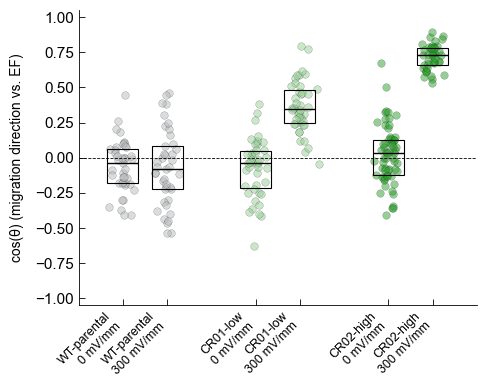

In [31]:
df_cos_theta_net_all = calc_cos_theta_net_per_trajectory(df_clusters)

sample_group_cols = ['celltype', 'E_V_cm', 'date', 'trial', 'scope', 'position']
df_sample_means = (
    df_cos_theta_net_all
    .groupby(sample_group_cols)
    .agg(mean_cos_theta=('cos_theta_net', 'mean'))
    .reset_index()
)

celltypes = ['WT-parental', 'CR01-low', 'CR02-high']
ef_levels = [0, 3]

x_positions = {}
x_tick_labels = []

group_spacing = 1.5
within_group_spacing = 0.5
x_base = 0

for ct in celltypes:
    for i, E in enumerate(ef_levels):
        xpos = x_base + i * within_group_spacing
        x_positions[(ct, E)] = xpos
        x_tick_labels.append(f"{ct}\n{int(E*100)} mV/mm")
    x_base += group_spacing

fig, ax = plt.subplots(figsize=(5, 4))
jitter_scale = 0.06

for (celltype, E), group in df_sample_means.groupby(['celltype', 'E_V_cm']):
    cos_vals = group['mean_cos_theta'].dropna().values
    if len(cos_vals) == 0:
        continue

    xpos = x_positions[(celltype, E)]
    jittered_x = np.random.normal(loc=xpos, scale=jitter_scale, size=len(cos_vals))

    ax.scatter(
        jittered_x, cos_vals,
        alpha=0.5, s=30, zorder=1,
        color=color_dict[celltype],
        edgecolor='k', linewidth=0.2
    )

    ax.boxplot(
        [cos_vals],
        positions=[xpos],
        widths=0.35,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor='none', edgecolor='black', linewidth=0.8),
        medianprops=dict(color='black', linewidth=1),
        whiskerprops=dict(color='none', linewidth=0),
        capprops=dict(color='none', linewidth=0),
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_tick_labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('cos(θ) (migration direction vs. EF)', fontsize=10)
ax.axhline(0, color='black', linestyle='--', linewidth=0.6)
ax.set_ylim(-1.05, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(width=0.6, length=4)
plt.tight_layout()




from scipy.stats import mannwhitneyu

results = []

for ct in df_sample_means['celltype'].unique():
    df_ct = df_sample_means[df_sample_means['celltype'] == ct]
    group_0 = df_ct[df_ct['E_V_cm'] == 0]['mean_cos_theta'].dropna()
    group_3 = df_ct[df_ct['E_V_cm'] == 3]['mean_cos_theta'].dropna()

    if len(group_0) < 2 or len(group_3) < 2:
        print(f"Not enough data to test {ct}")
        continue

    stat, p = mannwhitneyu(group_0, group_3, alternative='two-sided')
    results.append({
        'celltype': ct,
        'n_0': len(group_0),
        'n_3': len(group_3),
        'median_0': group_0.median(),
        'median_3': group_3.median(),
        'U_stat': stat,
        'p_value': p
    })

import pandas as pd
df_u_test = pd.DataFrame(results)
df_u_test.sort_values('p_value', inplace=True)

from IPython.display import display
display(df_u_test)

fig.savefig('../../figures/Figure4_MDCK_directionality_cluster.pdf')
3.076614e-01